Tingkat Penolakan Berdasarkan Cuaca:


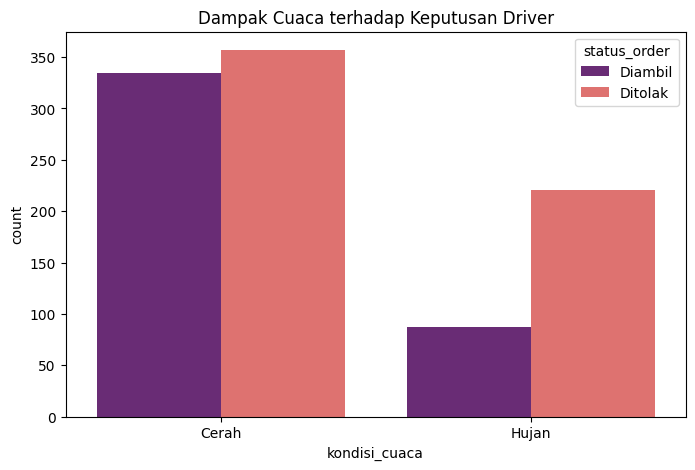


Akurasi Model: 0.69

Laporan Klasifikasi:
               precision    recall  f1-score   support

     Diambil       0.64      0.64      0.64        87
     Ditolak       0.73      0.73      0.73       113

    accuracy                           0.69       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.69      0.69      0.69       200



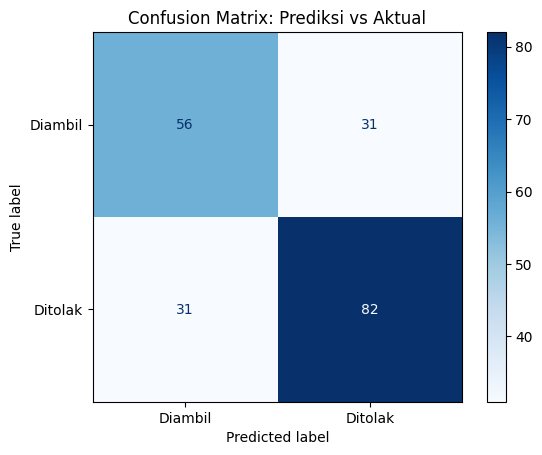

/tmp/ipykernel_1175/2448457928.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pentingnya', y='Fitur', data=feature_importance_df, palette='viridis')


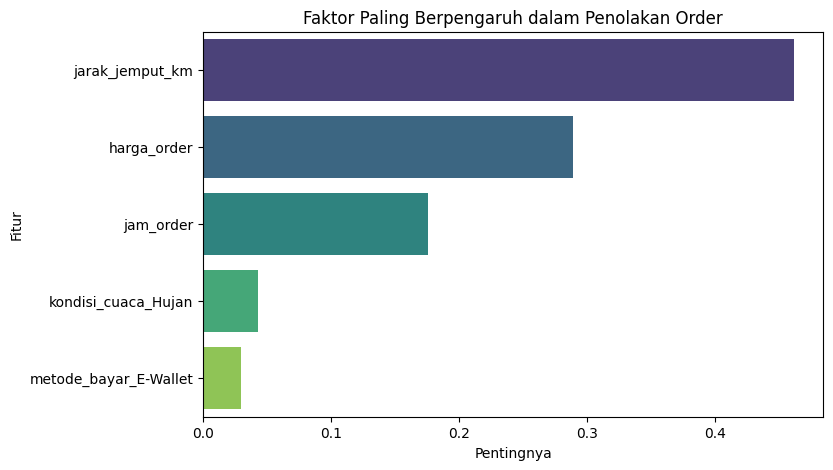


Hasil Prediksi: Ditolak
Probabilitas Ditolak: 89.00%


In [10]:
# ==========================================================
# PROYEK: PREDIKSI PENOLAKAN ORDER OLEH DRIVER (RIDE-HAILING)
# Dibuat oleh: Ramdaani
# ==========================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# --- 1. DATA GENERATION (Membuat Dataset Simulasi) ---
np.random.seed(42)
n_data = 1000

data = {
    'jarak_jemput_km': np.random.uniform(0.1, 5.0, n_data),
    'harga_order': np.random.randint(10000, 100000, n_data),
    'jam_order': np.random.randint(0, 24, n_data),
    'metode_bayar': np.random.choice(['Cash', 'E-Wallet'], n_data),
    'kondisi_cuaca': np.random.choice(['Cerah', 'Hujan'], n_data, p=[0.7, 0.3])
}

df = pd.DataFrame(data)

# Logika Driver: Simulasi perilaku nyata (pilih-pilih order)
def driver_decision(row):
    prob = 0.8
    if row['jarak_jemput_km'] > 1.5: prob -= 0.4
    if row['kondisi_cuaca'] == 'Hujan': prob -= 0.2
    if row['metode_bayar'] == 'Cash': prob -= 0.1
    return np.random.choice(['Diambil', 'Ditolak'], p=[max(0.1, prob), 1-max(0.1, prob)])

df['status_order'] = df.apply(driver_decision, axis=1)

# --- 2. EXPLORATORY DATA ANALYSIS (Visualisasi) ---
print("Tingkat Penolakan Berdasarkan Cuaca:")
plt.figure(figsize=(8,5))
sns.countplot(x='kondisi_cuaca', hue='status_order', data=df, palette='magma')
plt.title('Dampak Cuaca terhadap Keputusan Driver')
plt.show()

# --- 3. DATA PREPROCESSING FOR MACHINE LEARNING ---
# Mengubah data kategorikal menjadi angka
df_ml = pd.get_dummies(df, columns=['metode_bayar', 'kondisi_cuaca'], drop_first=True)

X = df_ml.drop('status_order', axis=1)
y = df_ml['status_order']

# Membagi data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. MODELING (Random Forest) ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- 5. EVALUATION ---
predictions = model.predict(X_test)
print(f"\nAkurasi Model: {accuracy_score(y_test, predictions)}")
print("\nLaporan Klasifikasi:\n", classification_report(y_test, predictions))

# Menampilkan Confusion Matrix
cm = confusion_matrix(y_test, predictions, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Prediksi vs Aktual')
plt.show()

# --- 6. FEATURE IMPORTANCE (Analisis Faktor Terpenting) ---
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Fitur': X.columns, 'Pentingnya': importances}).sort_values(by='Pentingnya', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Pentingnya', y='Fitur', data=feature_importance_df, palette='viridis')
plt.title('Faktor Paling Berpengaruh dalam Penolakan Order')
plt.show()

# --- 7. SIMULASI PREDIKSI NYATA (Deployment Sederhana) ---
def cek_risiko_penolakan(jarak, harga, jam, cash_0_wallet_1, cerah_0_hujan_1):
    input_data = pd.DataFrame([[jarak, harga, jam, cash_0_wallet_1, cerah_0_hujan_1]], columns=X.columns)
    hasil = model.predict(input_data)
    prob = model.predict_proba(input_data)
    print(f"\nHasil Prediksi: {hasil[0]}")
    print(f"Probabilitas Ditolak: {prob[0][1]*100:.2f}%")

# Contoh Testing: Jarak jemput 3.5km, Harga 15rb, Jam 17, E-Wallet, Hujan
cek_risiko_penolakan(3.5, 15000, 17, 1, 1)